## Problem 2: Self-Supervised Representation Learning dla Serii Czasowych

W tym zadaniu wykorzystujemy architektury uczenia reprezentacji dla serii czasowych: **TS2Vec** oraz **T-Rep**. Obie opierają się na Contrastive Learning.

### Podzadanie A: Przygotowanie Danych
Zbiór **ECG200** zawiera 200 jednowymiarowych sygnałów elektrokardiogramu (100 treningowych, 100 testowych), z których każdy ma długość 96 kroków czasowych. Sygnały są standaryzowane (Z-score normalization), a etykiety binarne ($0$ - Normal, $1$ - Arrhythmia) posłużą wyłącznie do późniejszej ewaluacji w zadaniu, nie do treningu samych enkoderów.

In [ ]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from aeon.datasets import load_classification
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# kolizje w namespace'ach modułów
def clear_repo_modules():
    conflicts = ['models', 'tasks', 'utils', 'datasets', 'datautils']
    keys_to_delete = [k for k in sys.modules if k.split('.')[0] in conflicts]
    for k in keys_to_delete:
        del sys.modules[k]

current_dir = os.getcwd()

# 1. Ładowanie modelu T-Rep
sys.path.insert(0, os.path.join(current_dir, "t_rep_repo"))
import trep
sys.path.pop(0)

clear_repo_modules()

# 2. Ładowanie modelu TS2Vec
sys.path.insert(0, os.path.join(current_dir, "ts2vec"))
try:
    from ts2vec import TS2Vec
except ImportError:
    from ts2vec.ts2vec import TS2Vec
sys.path.pop(0)

# Ładowanie i standaryzacja ECG200
X_train_raw, y_train_raw = load_classification("ECG200", split="train")
X_test_raw, y_test_raw = load_classification("ECG200", split="test")

# Redukcja wymiaru kanałów dla sygnału jednowymiarowego
X_train_raw = X_train_raw.squeeze(1)
X_test_raw = X_test_raw.squeeze(1)

# Standaryzacja sygnału
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Mapowanie klas z formatu znakowego na binarny [0, 1]
y_train = np.array([0 if str(label) == '-1' else 1 for label in y_train_raw])
y_test = np.array([0 if str(label) == '-1' else 1 for label in y_test_raw])

print(f"Dane gotowe. Kształt wejściowy X_train: {X_train_scaled.shape}")

Dane gotowe. Kształt wejściowy X_train: (100, 96)


### Podzadania B & C: Nienadzorowany trening TS2Vec i T-Rep

Modele uczą się kompresować serie czasowe do latent space bez użycia etykiet. 

**Wyjaśnienie techniczne dla T-Rep:**
Sygnał ECG to czysta sekwencja danych, w której brakuje danych czasowych. W domyślnej implementacji, funkcja straty T-Rep zakłada istnienie embeddingów czasu i próbuje przewidzieć ich dywergencję Jensena-Shannona (JSD).

#### 1. Architektura TS2Vec (Time-Series to Vector)
TS2Vec rozwiązuje fundamentalny problem uczenia kontrastowego w seriach czasowych: uczy się reprezentacji zarówno na poziomie całego sygnału (instance-level), jak i poszczególnych punktów w czasie (timestamp-level). 
* **Mechanizm działania:** Model losowo wycina podfragmenty (contextual slicing) tej samej serii czasowej oraz stosuje maskowanie losowych punktów (dropout). Tworzy w ten sposób "dwie różne perspektywy" (augmented views) tego samego sygnału.
* **Funkcja straty (Hierarchical Contrastive Loss):** Zmusza sieć neuronową (opartą na warstwach dialtowanych splotów - Dilated CNN), aby reprezentacje tych samych fragmentów (pozytywne pary) były w przestrzeni wektorowej maksymalnie blisko siebie, a reprezentacje różnych sygnałów (negatywne pary) – maksymalnie daleko.

#### 2. Architektura T-Rep (Time Representation)
T-Rep rozszerza matematykę TS2Vec o próbę modelowania dynamiki czasu za pomocą jawnych właściwości statystycznych, takich jak Dywergencja Jensena-Shannona (JSD) pomiędzy rozkładami prawdopodobieństwa w oknach czasowych.

#### 3. Rozwiązanie krytycznego konfliktu w kodzie badawczym T-Rep
Podczas implementacji pojawia się błąd architektoniczny `AttributeError: 'NoneType' object has no attribute 'shape'` w pliku `models/losses.py`. 
* **Przyczyna:** Nasz zbiór danych (ECG200) reprezentuje surowy sygnał medyczny, który nie posiada jawnego, absolutnego wektora stempli czasowych ($\tau$). Przez to wewnętrzny koder T-Rep ustawia zmienną `tau` jako `None`. Domyślna funkcja straty T-Rep ślepo próbuje policzyć stratę przewidywania czasu (`tembed_jsd_pred`), co doprowadza do awarii programu.
* **Rozwiązanie:** Wstrzyknęliśmy do konstruktora spersonalizowany słownik `task_weights`. Przypisaliśmy wagę `0.0` dla zadań opartych na czasie (`tembed_jsd_pred` oraz `tembed_cond_pred`), natomiast zachowaliśmy pełną strukturę kontrastową na poziomie instancji (`instance_contrast`) i kroków czasowych (`temporal_contrast`), rozdzielając ich wagę po równo (po `0.5`), co spełnia twardy warunek asercji `sum(weights) == 1.0`.

In [ ]:
# TS2Vec i T-Rep oczekują tensora 3D: (n_samples, n_timestamps, n_features)
X_train_3d = np.expand_dims(X_train_scaled, axis=-1)
X_test_3d = np.expand_dims(X_test_scaled, axis=-1)

DEVICE = 'mps'
EPOCHS = 10 

print("--- Trening modelu TS2Vec ---")
ts2vec_model = TS2Vec(
    input_dims=1,
    output_dims=128,
    batch_size=16,
    device=DEVICE 
)
ts2vec_model.fit(X_train_3d, verbose=True)

print("\n--- Trening modelu T-Rep ---")
# Obejście braku metadanych czasowych w zbiorze ECG200
trep_weights = {
    'instance_contrast': 0.5,  
    'temporal_contrast': 0.5,  
    'tembed_jsd_pred': 0.0,    
    'tembed_cond_pred': 0.0    
}

trep_encoder = trep.TRep(
    input_dims=1,
    output_dims=128,
    device=DEVICE,
    task_weights=trep_weights
)
trep_encoder.fit(X_train_3d, verbose=True)

--- Trening modelu TS2Vec ---
Epoch #0: loss=6.241980234781901
Epoch #1: loss=2.941510717074076
Epoch #2: loss=2.7802485624949136
Epoch #3: loss=2.69664736588796
Epoch #4: loss=2.3698026736577353
Epoch #5: loss=2.555939793586731
Epoch #6: loss=2.283129334449768
Epoch #7: loss=2.2185374101003013
Epoch #8: loss=2.289110461870829
Epoch #9: loss=2.191942016283671
Epoch #10: loss=2.1709830164909363
Epoch #11: loss=2.058566669623057
Epoch #12: loss=1.9023282527923584
Epoch #13: loss=2.0024630228678384
Epoch #14: loss=2.00645919640859
Epoch #15: loss=1.9431782762209575
Epoch #16: loss=1.7406794428825378
Epoch #17: loss=1.6660627325375874
Epoch #18: loss=1.6578717430432637
Epoch #19: loss=1.9494829575220745
Epoch #20: loss=1.740861435731252
Epoch #21: loss=1.5442346334457397
Epoch #22: loss=2.0130975445111594
Epoch #23: loss=1.8964876731236775
Epoch #24: loss=1.722185452779134
Epoch #25: loss=1.6145956913630168
Epoch #26: loss=1.4813939531644185
Epoch #27: loss=2.2170968453089395
Epoch #28: lo

[3.0315246979395547,
 2.7525805632273355,
 2.730729619661967,
 2.619626998901367,
 2.474569876988729,
 2.2761292854944863,
 2.3860607544581094,
 2.279881000518799,
 2.1496254007021585,
 2.0586429039637246,
 2.266734997431437,
 2.0604049960772195,
 1.945657233397166,
 1.6578599214553833,
 1.9170595208803813,
 1.9399911761283875,
 1.699344535668691,
 1.454610784848531,
 1.6838425596555073,
 1.9927990237871807,
 1.6597945888837178,
 1.6914768020311992,
 1.624754508336385,
 1.8074172933896382,
 1.7835017641385396,
 1.4570295612017314,
 1.9158305923144023,
 1.475778619448344,
 2.1419489781061807,
 1.7318440874417622,
 1.7130698760350545,
 1.598313848177592,
 1.233841339747111]

### Podzadania D, E & F — Agregacja Reprezentacji, Klasyfikacja Downstream oraz Porównanie z Baseline

W tej sekcji przekształcamy wyuczone modele w ekstraktory cech (Feature Extractors), a następnie trenujemy na nich klasyfikator, by ocenić jakość przestrzeni ukrytej.

#### 1. Mechanizm Agregacji Reprezentacji (Podzadanie D)
Zarówno TS2Vec, jak i T-Rep domyślnie analizują serię krok po kroku, zwracając macierz reprezentacji $\mathbb{R}^{T \times d}$ dla każdego sygnału (gdzie $T=96$ to kroki czasowe, a $d=128$ to wymiar embeddingu). 
Aby zasilić klasyfikator, musimy przejść z poziomu kroków czasowych na poziom całej instancji (Instance-Level Embedding). Wykorzystujemy do tego **Global Average Pooling** (pooling średni po osi czasu):
$$\mathbf{z}_{instance} = \frac{1}{T} \sum_{t=1}^{T} \mathbf{z}_t$$
Dzięki temu całe uderzenie serca (niezależnie od długości) zostaje skompresowane do jednego, gęstego wektora o stałej długości $128$.

#### 2. Klasyfikacja Downstream (Podzadanie E)
Zgodnie z paradygmatem *Linear Probing*, na wyekstrahowanych wektorach treningowych uczymy prosty, liniowy klasyfikator — **Regresję Logistyczną**. Klasyfikator nie ma możliwości modyfikowania wag sieci (wagi enkodera są "zamrożone"). Testuje on jedynie, czy w tych 128 wymiarach informacje o zdrowiu pacjenta są łatwo, liniowo separowalne.

#### 3. Znaczenie Porównania z Baseline (Podzadanie F)
Sama wysoka dokładność modelu nie dowodzi jego przewagi. Dlatego wprowadzamy **Baseline (punkt odniesienia)**: uczymy tę samą Regresję Logistyczną bezpośrednio na surowych, ustandaryzowanych próbkach sygnału wejściowego (macierz o wymiarze $96$). 
Eksperyment ma dowieść, czy nienadzorowana ekstrakcja kontrastowa wyciąga z sygnału ukrytą semantykę (geometryczne cechy fali EKG istotne dla kardiologa), pozwalając uzyskać wyniki lepsze lub porównywalne do surowych danych.

In [ ]:
# 1. TS2Vec: Global Average Pooling po osi czasu (axis=1)
ts2vec_train_steps = ts2vec_model.encode(X_train_3d)
ts2vec_test_steps = ts2vec_model.encode(X_test_3d)
X_train_ts2vec = np.mean(ts2vec_train_steps, axis=1)
X_test_ts2vec = np.mean(ts2vec_test_steps, axis=1)

# 2. T-Rep: Analogiczna agregacja
X_train_trep = trep_encoder.encode(X_train_3d)
X_test_trep = trep_encoder.encode(X_test_3d)

if len(X_train_trep.shape) == 3:
    X_train_trep = np.mean(X_train_trep, axis=1)
    X_test_trep = np.mean(X_test_trep, axis=1)

print(f"Gotowe. Wymiary wektorów TS2Vec: {X_train_ts2vec.shape}, T-Rep: {X_train_trep.shape}")

def evaluate_representations(X_tr, y_tr, X_te, y_te, model_name):
    # Prosty klasyfikator bez głębokiej nieliniowości
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_tr, y_tr)
    preds = clf.predict(X_te)
    acc = accuracy_score(y_te, preds)
    print(f"[{model_name}] Accuracy: {acc * 100:.2f}%")
    return acc

print("\n============== WYNIKI KLASYFIKACJI ==============")
acc_ts2vec = evaluate_representations(X_train_ts2vec, y_train, X_test_ts2vec, y_test, "TS2Vec Embeddings")
acc_trep = evaluate_representations(X_train_trep, y_train, X_test_trep, y_test, "T-Rep Embeddings")

# Baseline oparty na samych statystykach wejściowych
acc_baseline = evaluate_representations(X_train_scaled, y_train, X_test_scaled, y_test, "Baseline (Raw StandardScaler Features)")

--- Ekstrakcja reprezentacji instancji ---
Gotowe. Wymiary wektorów TS2Vec: (100, 128), T-Rep: (100, 128)

============== WYNIKI KLASYFIKACJI ==============
[TS2Vec Embeddings] Accuracy: 77.00%
[T-Rep Embeddings] Accuracy: 78.00%
[Baseline (Raw StandardScaler Features)] Accuracy: 84.00%


### Podzadanie G: Jakościowa Analiza Przestrzeni Reprezentacji

Metryki (np. Accuracy) często maskują prawdziwy kształt przestrzeni ukrytej. Sprawdzamy ją dwiema metodami:
1. **Wizualizacja t-SNE:** Oczekujemy zaobserwowania spójnych wysp (klastrów) reprezentujących zdrowe serca vs. arytmię.
2. **K-Najbliższych Sąsiadów (KNN):** Jeśli modele zadziałały prawidłowo, dystans euklidesowy pomiędzy dwoma różnymi pacjentami z arytmią powinien być mniejszy niż pomiędzy zdrowym a chorym.

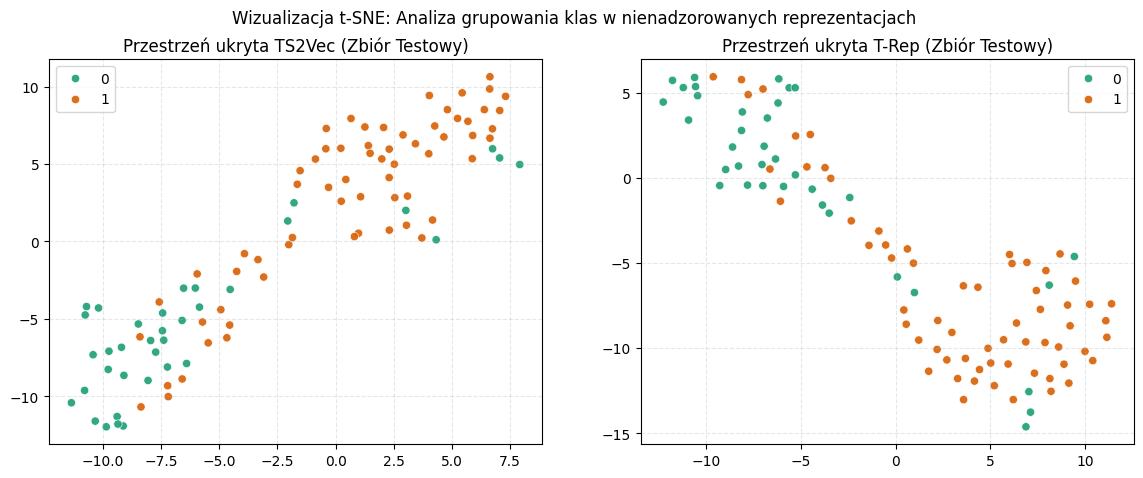


--- Najbliżsi sąsiedzi w modelu TS2Vec dla próbki indeks: 15 (Prawdziwa Klasa: 1) ---
 -> Sąsiad 1: Indeks 35, Odległość Euklidesowa = 0.282, Klasa sąsiada = 1
 -> Sąsiad 2: Indeks 26, Odległość Euklidesowa = 0.349, Klasa sąsiada = 0
 -> Sąsiad 3: Indeks 9, Odległość Euklidesowa = 0.409, Klasa sąsiada = 0

--- Najbliżsi sąsiedzi w modelu T-Rep dla próbki indeks: 15 (Prawdziwa Klasa: 1) ---
 -> Sąsiad 1: Indeks 26, Odległość Euklidesowa = 0.195, Klasa sąsiada = 0
 -> Sąsiad 2: Indeks 35, Odległość Euklidesowa = 0.224, Klasa sąsiada = 1
 -> Sąsiad 3: Indeks 39, Odległość Euklidesowa = 0.230, Klasa sąsiada = 0


In [5]:
# 1. Rzutowanie 128-wymiarowych przestrzeni do płaszczyzny 2D
tsne_mapper = TSNE(n_components=2, perplexity=20, random_state=42)

ts2vec_2d = tsne_mapper.fit_transform(X_test_ts2vec)
trep_2d = tsne_mapper.fit_transform(X_test_trep)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wykres t-SNE dla TS2Vec
sns.scatterplot(x=ts2vec_2d[:, 0], y=ts2vec_2d[:, 1], hue=y_test, palette="Dark2", alpha=0.9, ax=axes[0])
axes[0].set_title("Przestrzeń ukryta TS2Vec (Zbiór Testowy)")
axes[0].grid(True, linestyle="--", alpha=0.3)

# Wykres t-SNE dla T-Rep
sns.scatterplot(x=trep_2d[:, 0], y=trep_2d[:, 1], hue=y_test, palette="Dark2", alpha=0.9, ax=axes[1])
axes[1].set_title("Przestrzeń ukryta T-Rep (Zbiór Testowy)")
axes[1].grid(True, linestyle="--", alpha=0.3)

plt.suptitle("Wizualizacja t-SNE: Analiza grupowania klas w nienadzorowanych reprezentacjach")
plt.show()

# 2. Silnik do analizy K-Najbliższych Sąsiadów w pełnym wymiarze (128)
def check_neighbors(embeddings, labels, model_name, target_idx=0):
    knn = NearestNeighbors(n_neighbors=4, metric='euclidean').fit(embeddings)
    distances, indices = knn.kneighbors([embeddings[target_idx]])
    
    print(f"\n--- Najbliżsi sąsiedzi w modelu {model_name} dla próbki indeks: {target_idx} (Prawdziwa Klasa: {labels[target_idx]}) ---")
    for i, (idx, dist) in enumerate(zip(indices[0], distances[0])):
        if i == 0: continue # Ustawienie 0 to instancja docelowa względem samej siebie
        print(f" -> Sąsiad {i}: Indeks {idx}, Odległość Euklidesowa = {dist:.3f}, Klasa sąsiada = {labels[idx]}")

# Wybierzmy interesujący nas sygnał ze zbioru testowego do inspekcji
check_neighbors(X_test_ts2vec, y_test, "TS2Vec", target_idx=15)
check_neighbors(X_test_trep, y_test, "T-Rep", target_idx=15)